# UPSC Essay Evaluation System — LangGraph Flow
> The system begins at the Topic Generator Node, which generates a random UPSC essay topic for the user. The user then writes the essay in the Human Input step, after which the Essay Input Node loads the written essay into the graph state.
> The essay then flows into three parallel evaluator nodes simultaneously. The Language Quality Evaluator checks grammar, vocabulary, and clarity of expression. The Clear Thought Evaluator checks logical flow, structure, and argument coherence. The Relevance Evaluator checks alignment with the given topic and depth of coverage.
> Once all three evaluators complete their analysis, the results flow into two separate nodes. The Feedback Node consolidates feedback from all three evaluators into a single comprehensive report. The Score Node generates a final score between 0 and 10 based on a weighted average of all three evaluations.
> Both nodes then merge at the END, producing the final output — a complete report containing both the consolidated feedback and the final score.

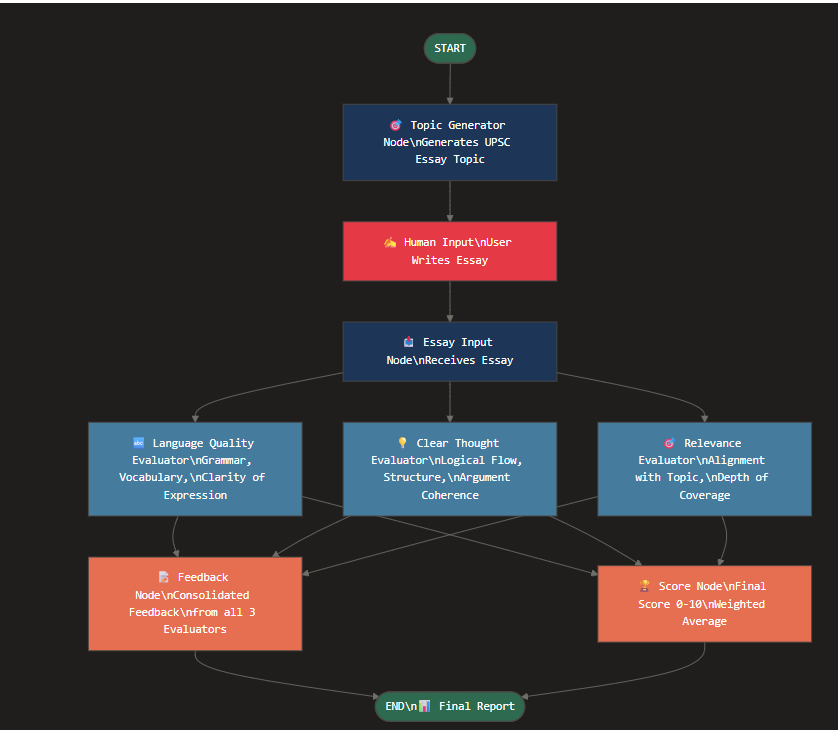

In [230]:
# Import Libraries 
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Literal, Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain.agents import create_agent
from langchain_community.tools import BaseTool, Tool, DuckDuckGoSearchResults
from pydantic import BaseModel, Field
from langchain_core.output_parsers import *
import numpy as np





from dotenv import load_dotenv
load_dotenv()

True

In [231]:
# Define Pydantic base model for structural output

class ScoreClass(BaseModel):
    score: float = Field(..., description="The score for the specific task")
    feedback : str = Field(..., description="Feedback generated from the llm")

# Define the topic class
class TopicClass(BaseModel):
    topic: str = Field(..., description="The topic for the UPSC candidate", max_length=100)    

In [232]:
# Define the llm
llm = ChatOpenAI(model = 'gpt-4o-mini',max_completion_tokens = 600)
llm_with_structure_score = llm.with_structured_output(schema=ScoreClass)
llm_with_structure_topic = llm.with_structured_output(schema=TopicClass)

In [233]:
# # testing the llm_with_structure
# x=llm_with_structure_topic.invoke("""One trending topic for the UPSC Civil Services Preliminary Exam is the "Revised and Updated Course for UPSC Civil Services Preliminary Exam 2023." This revision focuses on essential current affairs and topics that are crucial for aspirants preparing for the exam.\n\nFor more information, you can check related articles, such as those published by Best Current Affairs.""")
# x.topic

In [234]:
# define the State 

class BaseStateClass(TypedDict):
    topic : str 
    essay : str 
    language_score : float 
    language_feedback: str 
    thought_score : float
    thought_feedback:str

    relevance_score : float
    relevance_feedback: str 
    overall_score : float 
    feed_back : str 



In [235]:
# Topic generation Node

def topicNode(state : BaseStateClass):
    topic_prompt = PromptTemplate.from_template(
        """You are a topic generator for UPSC government exam,
    generate only 1 trending topic by doing internet search 
    """
    )

    duck_tool = DuckDuckGoSearchResults()

    topic_agent = create_agent(
        model = llm , 
        tools = [duck_tool]
    )

    res = topic_agent.invoke({'messages': [HumanMessage(topic_prompt.format())]})
    topic_pre=res['messages'][-1].content
    topic = llm_with_structure_topic.invoke(topic_pre)
    
    return { "topic" : topic.topic }

In [236]:
# Get the essay from the candidate
def GetTheEssay(state : BaseStateClass):
    essay = input(f"Write The essay on Topic {state['topic']}, word limit 500")

    return {"essay" : essay}

In [237]:
# Language quality 

def LanguageQualityChecker(state : BaseStateClass):
    language_quality_score_prompt = PromptTemplate.from_template("""
        You are a strict essay quality of language evaluator for UPSC exam. 
        Evaluate the language quality of the essay on given topic and 
        generate score between 0-10 in float and also give a detail feedback on language quality in the essay max 100 words.

            topic : "{topic}"

            essay : "{essay}"

            feedback :
            score:
            
            """
            )
    chain = language_quality_score_prompt | llm | StrOutputParser() 
    language_score= chain.invoke({"topic" : state['topic'], "essay": state['essay']})
    score_invoke = llm_with_structure_score.invoke(language_score)
    
    score = score_invoke.score 
    feedback = score_invoke.feedback

    return {'language_score': score, 'language_feedback': feedback}

In [238]:
# thought quality node

def ThoughtQualityChecker(state : BaseStateClass):
    thought_quality_score_prompt = PromptTemplate.from_template("""
        You are a strict essay's clarity of thought evaluator for UPSC exam. 
        Evaluate the clarity of thought of the essay on given topic and 
        generate score between 0-10 in float and also give a detail feedback on clarity of thought on the given essay max 100 words.

            topic : "{topic}"

            essay : "{essay}"

            feedback :
            score:
            
            """
            )
    chain = thought_quality_score_prompt | llm | StrOutputParser() 
    thought_score= chain.invoke({"topic" : state['topic'], "essay": state['essay']})
    score_invoke = llm_with_structure_score.invoke(thought_score)
    
    score = score_invoke.score 
    feedback = score_invoke.feedback

    return {'thought_score': score, 'thought_feedback': feedback}

In [239]:
# relevance on the topic node

def RelevanceChecker(state : BaseStateClass):
    relevance_quality_score_prompt = PromptTemplate.from_template("""
        You are a strict essay's topic relevancy evaluator for UPSC exam. 
        Evaluate the relevancy the essay on given topic and 
        generate score between 0-10 in float and also give a detail feedback on relevancy on the topic
        on the given essay max 100 words.

            topic : "{topic}"

            essay : "{essay}"
            
            feedback :
            score:
            """
            )

    chain = relevance_quality_score_prompt | llm | StrOutputParser() 
    rel_score= chain.invoke({"topic" : state['topic'], "essay": state['essay']})
    score_invoke = llm_with_structure_score.invoke(rel_score)
    
    score = score_invoke.score 
    feedback = score_invoke.feedback

    return {'relevance_score': score, 'relevance_feedback': feedback}

In [240]:
def overallFeedback(state: BaseStateClass):
    overall_feedback_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', """
            You are a essay evaluator for upsc exam. 
            Evaluate the overall feedback on Given topic , content from the 3 different evaluators feedback 

            language feedback : "{language_feedback}"
            clarity of thought feedback : "{thought_feedback}"
            relevance feedback : "{relevance_feedback}"

            topic : "{topic}"

            Feedback:
            
            """)
        ]
    )

    input_x = {"language_feedback": state["language_feedback"], 
                "thought_feedback": state["thought_feedback"],
                "relevance_feedback": state["relevance_feedback"],
                "topic": state['topic'] }

    chain = overall_feedback_prompt | llm | StrOutputParser()
    state['feed_back'] = chain.invoke(input_x)
    state['overall_score'] = np.round(np.mean(np.array([[state["language_score"], state['relevance_score'], state['thought_score']]]),1))

    return state

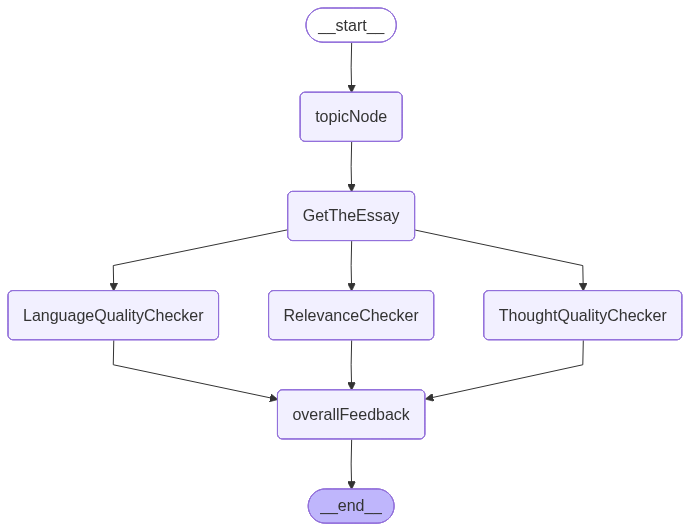

In [241]:
# define the graph
graph = StateGraph(BaseStateClass)

# add nodes 

graph.add_node("topicNode", topicNode)
graph.add_node("GetTheEssay", GetTheEssay)
graph.add_node("LanguageQualityChecker", LanguageQualityChecker)
graph.add_node("ThoughtQualityChecker", ThoughtQualityChecker)
graph.add_node("RelevanceChecker", RelevanceChecker)
graph.add_node("overallFeedback", overallFeedback)

# add edges 

graph.add_edge(START, "topicNode")
graph.add_edge("topicNode", "GetTheEssay")

graph.add_edge("GetTheEssay", "LanguageQualityChecker")
graph.add_edge("GetTheEssay", "ThoughtQualityChecker")
graph.add_edge("GetTheEssay", "RelevanceChecker")

graph.add_edge("LanguageQualityChecker", "overallFeedback")
graph.add_edge("ThoughtQualityChecker", "overallFeedback")
graph.add_edge("RelevanceChecker", "overallFeedback")

graph.add_edge("overallFeedback", END)

# compile the graph 
work_flow = graph.compile()

# visualize the graph
work_flow

In [242]:
# initial state
initial_state= { "topic" : None,
    "essay" : None,
    "language_score" : 0.0,
    "language_feedback": None ,
    "thought_score" : 0.0,
    "thought_feedback":None,

    "relevance_score" : 0.0,
    "relevance_feedback": None ,
    "overall_score" : 0.0 ,
    "feed_back" : None }

In [243]:
response=work_flow.invoke(input=initial_state)

In [245]:
response

{'topic': 'The Impact of Cloud Computing on the Legal Sector in India',
 'essay': 'Cloud computing has significantly transformed the legal sector in India by improving efficiency, accessibility, and data management. Law firms and courts increasingly rely on cloud platforms to store documents, manage case files, and enable remote collaboration. This shift has reduced operational costs and enhanced flexibility, allowing legal professionals to access information anytime, anywhere. During and after the COVID-19 pandemic, cloud-based tools supported virtual hearings and digital case management, accelerating the adoption of e-courts.  However, the use of cloud computing also raises concerns about data security, privacy, and compliance with legal regulations. Sensitive client information must be protected from breaches and unauthorized access. Therefore, robust cybersecurity measures and clear data protection laws are essential. Overall, cloud computing is modernizing India’s legal system, bu

In [246]:
print(response["feed_back"])

### Overall Feedback on the Essay 

The essay on "The Impact of Cloud Computing on the Legal Sector in India" presents a balanced analysis of the topic while effectively addressing both the positive impacts and challenges associated with cloud computing in this specific context. 

#### Strengths:

1. **Language Proficiency**: The essay demonstrates clear and coherent language, with a logical flow of ideas. The vocabulary is appropriate for the subject matter, and technical terms are well-integrated, which is crucial in discussing a complex topic like cloud computing.

2. **Clarity of Thought**: The essay does a commendable job of articulating the efficiency gains and operational flexibility that cloud computing brings to the legal sector. The progression of thoughts is logical, moving from advantages to potential pitfalls, which allows for a clearer understanding of the subject matter.

3. **Relevance to the Topic**: The discussion effectively highlights the transformative nature of cl

'The essay is extremely brief and lacks depth, providing only a superficial statement about love. It does not explore the complexities, types, or implications of love, nor does it present any personal insights or examples that would enhance its relevance to the topic. Additionally, it fails to engage with the broader societal or philosophical aspects of love that could make for a more compelling discussion.'